In [1]:
# Import TensorFlow and the specific Fashion MNIST dataset
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist
# Import Pandas and Numpy for data handling
import pandas as pd
import numpy as np
# Import Matplotlib for drawing our images and custom graphs
import matplotlib.pyplot as plt
# Import tools to build the network, specifically adding 'Flatten' for images
from keras.models import Sequential
from keras.layers import Dense, Flatten
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from IPython.display import display
import warnings
warnings.simplefilter('ignore')

# 1. LOAD DATA: Keras automatically splits the dataset for us!
# X = Images (28x28 pixels), y = Answers (Labels 0-9)
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

# 2. DEFINE LABELS: The dataset uses numbers 0-9. We map them to real text words.
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

print("✅ Data loaded! Training Images:", len(X_train), " | Testing Images:", len(X_test))

✅ Data loaded! Training Images: 60000  | Testing Images: 10000


In [ ]:
# PIXEL SCALING: This takes the place of StandardScaler from Practicum 1!
# A pixel's raw color value goes from 0 (Black) to 255 (White). Neural networks struggle with big numbers.
# We divide every pixel in the training images by 255.0 to force the values into a clean 0.0 to 1.0 decimal scale.
X_train_scaled = X_train / 255.0
# We perform the exact same division on the hidden testing images so they match the training format
X_test_scaled = X_test / 255.0

# Print a visual confirmation that the mathematical scaling is complete
print("✅ Images successfully scaled to 0.0 - 1.0 range.")

✅ Images successfully scaled to 0.0 - 1.0 range.


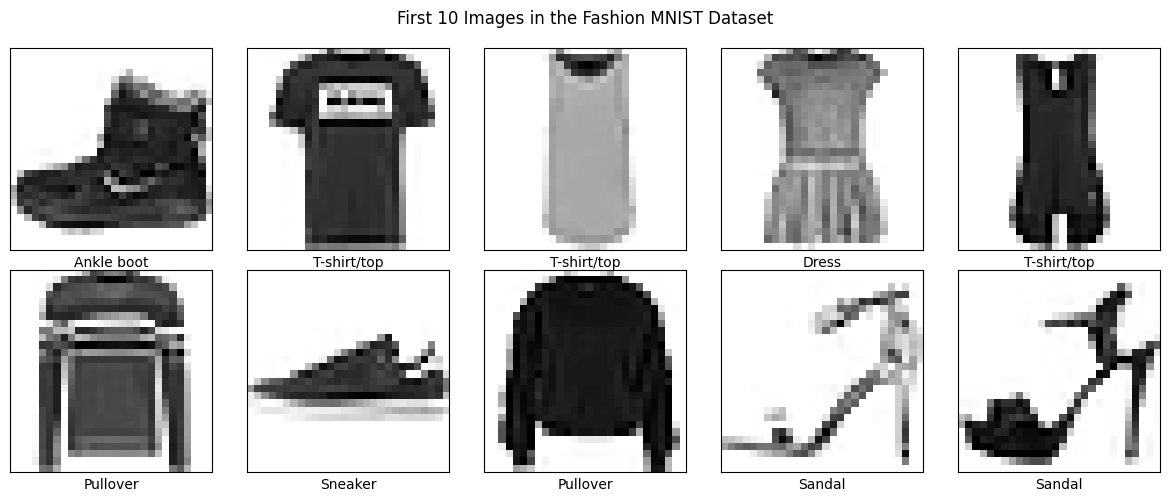

In [ ]:
# Create a blank drawing canvas that is 12 inches wide and 5 inches tall
plt.figure(figsize=(12, 5))

# Start a loop that will run exactly 10 times to draw the first 10 images
for i in range(10):
    # Tell Matplotlib to create a grid with 2 rows and 5 columns, and select the current slot (1 through 10)
    plt.subplot(2, 5, i+1)
    # Hide the X-axis numbers (we don't need to see the pixel coordinate numbers)
    plt.xticks([])
    # Hide the Y-axis numbers
    plt.yticks([])
    # Draw the actual image data from X_train, forcing the color map to be strictly black and white (binary)
    plt.imshow(X_train[i], cmap=plt.cm.binary)
    # Add a text label under the image by looking up the correct word in our class_names list using the y_train answer key
    plt.xlabel(class_names[y_train[i]])

# Add a giant master title above the entire 2x5 grid
plt.suptitle("First 10 Images in the Fashion MNIST Dataset")
# Automatically adjust the spacing so the titles and images don't overlap with each other
plt.tight_layout()
# Render the final image grid to the screen
plt.show()

In [ ]:
# Print a simple header text to the screen
print("--- RUNNING WARM-UP TEST ---")

# Initialize an empty, straight-line neural network
test_model = Sequential()
# THE FLATTEN LAYER: Neural networks cannot read 2D grids (28x28). 
# This layer stretches the image out into a single, straight line of 784 pixels.
test_model.add(Flatten(input_shape=(28, 28)))
# Add a single hidden processing layer with 128 nodes, using ReLU to block negative noise
test_model.add(Dense(128, activation='relu'))
# THE OUTPUT LAYER: We have exactly 10 clothing categories, so we MUST have exactly 10 output nodes.
# 'softmax' mathematically forces all 10 nodes to output probabilities that add up to exactly 100%.
test_model.add(Dense(10, activation='softmax'))

# LOSS FUNCTION: Because we are choosing between 10 categories (not just 2), we MUST use sparse_categorical_crossentropy
test_model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
# Train this basic model for a quick 3 epochs just to prove the architecture works without crashing
test_model.fit(X_train_scaled, y_train, epochs=3, batch_size=32, verbose=1)

# Print a header for our test predictions
print("\n--- TEST PREDICTIONS ---")
# Give the model the first 5 hidden test images and ask it to calculate the probabilities
y_pred_probs = test_model.predict(X_test_scaled[:5]) 
# np.argmax looks at the 10 probability scores for each image and picks the index (0-9) with the highest score
y_pred_labels = np.argmax(y_pred_probs, axis=1)

# Loop through our 5 predictions one by one
for i, prediction in enumerate(y_pred_labels):
    # Print what the model guessed vs what the true answer actually was
    print(f"Image {i+1}: Model guessed '{class_names[prediction]}' | Actual was '{class_names[y_test[i]]}'")

--- RUNNING WARM-UP TEST ---
Epoch 1/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8248 - loss: 0.5001
Epoch 2/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8640 - loss: 0.3760
Epoch 3/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8771 - loss: 0.3333

--- TEST PREDICTIONS ---
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
Image 1: Model guessed 'Ankle boot' | Actual was 'Ankle boot'
Image 2: Model guessed 'Pullover' | Actual was 'Pullover'
Image 3: Model guessed 'Trouser' | Actual was 'Trouser'
Image 4: Model guessed 'Trouser' | Actual was 'Trouser'
Image 5: Model guessed 'Shirt' | Actual was 'Shirt'


Starting 10 Image Experiments...

✅ Exp 1 done! -> Accuracy: 88.05%
✅ Exp 2 done! -> Accuracy: 88.06%
✅ Exp 3 done! -> Accuracy: 88.00%
✅ Exp 4 done! -> Accuracy: 88.56%
✅ Exp 5 done! -> Accuracy: 88.48%
✅ Exp 6 done! -> Accuracy: 88.88%
✅ Exp 7 done! -> Accuracy: 85.21%
✅ Exp 8 done! -> Accuracy: 87.43%
✅ Exp 9 done! -> Accuracy: 87.57%
✅ Exp 10 done! -> Accuracy: 88.70%


,Experiment ID,Layers,Description,Accuracy
0,1,1,Baseline,0.8805
1,2,1,Wider,0.8806
2,3,2,Deeper,0.8800
3,4,2,Very Wide,0.8856
4,5,3,3 Layers,0.8848
5,6,2,More Epochs,0.8888
6,7,2,High LR,0.8521
7,8,2,Low LR,0.8743
8,9,2,Big Batch,0.8757
9,10,3,Max Power,0.8870


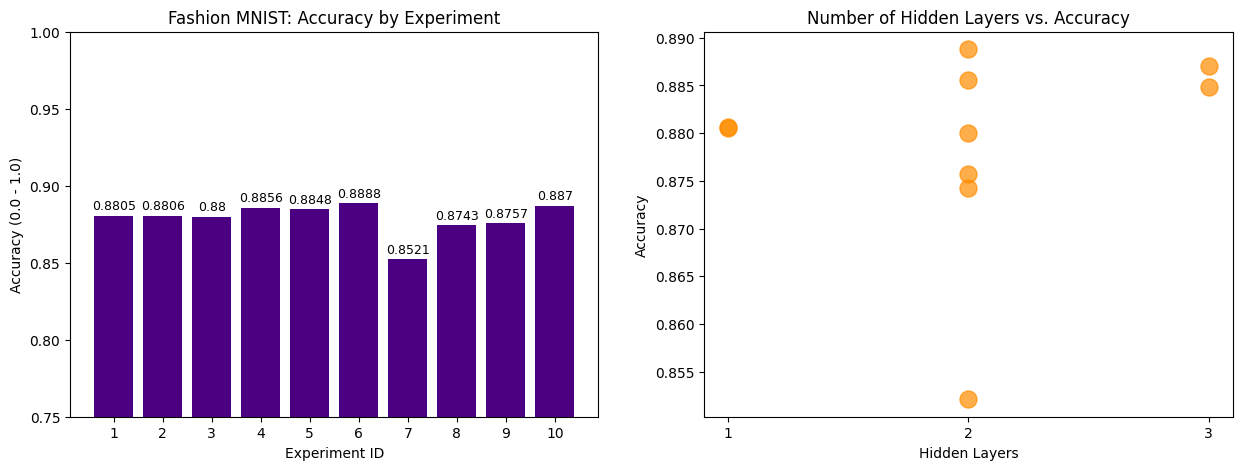

In [ ]:
# Create our blueprint "to-do list" of 10 different network architectures to test
experiments = [
    {'id': 1, 'layers': 1, 'nodes': [64], 'epochs': 10, 'batch': 32, 'lr': 0.001, 'note': 'Baseline'},
    {'id': 2, 'layers': 1, 'nodes': [128], 'epochs': 10, 'batch': 32, 'lr': 0.001, 'note': 'Wider'},
    {'id': 3, 'layers': 2, 'nodes': [128, 64], 'epochs': 10, 'batch': 32, 'lr': 0.001, 'note': 'Deeper'},
    {'id': 4, 'layers': 2, 'nodes': [256, 128], 'epochs': 10, 'batch': 32, 'lr': 0.001, 'note': 'Very Wide'},
    {'id': 5, 'layers': 3, 'nodes': [256, 128, 64], 'epochs': 10, 'batch': 32, 'lr': 0.001, 'note': '3 Layers'},
    {'id': 6, 'layers': 2, 'nodes': [128, 64], 'epochs': 20, 'batch': 32, 'lr': 0.001, 'note': 'More Epochs'},
    {'id': 7, 'layers': 2, 'nodes': [128, 64], 'epochs': 10, 'batch': 32, 'lr': 0.01, 'note': 'High LR'},
    {'id': 8, 'layers': 2, 'nodes': [128, 64], 'epochs': 10, 'batch': 32, 'lr': 0.0001, 'note': 'Low LR'},
    {'id': 9, 'layers': 2, 'nodes': [128, 64], 'epochs': 10, 'batch': 128, 'lr': 0.001, 'note': 'Big Batch'},
    {'id': 10, 'layers': 3, 'nodes': [512, 256, 128], 'epochs': 20, 'batch': 32, 'lr': 0.001, 'note': 'Max Power'}
]

# Create an empty list to store the final accuracy grades for each experiment
results = []
# Print a starting message to the screen
print("Starting 10 Image Experiments...\n")

# Loop through every single blueprint in our experiments list
for exp in experiments:
    # Initialize a fresh, empty neural network
    model = Sequential()
    # ALL image models must start with Flatten to stretch the 28x28 grid into a 1D line
    model.add(Flatten(input_shape=(28, 28)))
    
    # Loop dynamically based on how many hidden layers the current blueprint asks for
    for i in range(exp['layers']):
        # Add a Dense hidden layer with the specific number of nodes requested by the blueprint
        model.add(Dense(exp['nodes'][i], activation='relu'))
            
    # Add the final output layer for our 10 clothing classes using Softmax
    model.add(Dense(10, activation='softmax')) 
    
    # Compile the model using sparse_categorical for multi-class, and inject the specific learning rate
    model.compile(loss='sparse_categorical_crossentropy', optimizer=Adam(learning_rate=exp['lr']), metrics=['accuracy'])
    # Train the model using the blueprint's epochs and batch size. verbose=0 keeps the screen clean.
    model.fit(X_train_scaled, y_train, epochs=exp['epochs'], batch_size=exp['batch'], verbose=0)
    
    # Test the model on the hidden data and extract the accuracy score
    loss, accuracy = model.evaluate(X_test_scaled, y_test, verbose=0)
    
    # Save the experiment details and its final score into our results bucket
    results.append({
        'Experiment ID': exp['id'],
        'Layers': exp['layers'], # We explicitly save the layer count so we can use it in the scatter plot below!
        'Description': exp['note'],
        'Accuracy': round(accuracy, 4)
    })
    # Print a single-line update so we know the computer hasn't frozen
    print(f"✅ Exp {exp['id']} done! -> Accuracy: {accuracy*100:.2f}%")

# Convert our list of results into a formatted Pandas DataFrame table
df_results = pd.DataFrame(results)
# Render the table beautifully inside the notebook
display(df_results) 

# --- CUSTOM VISUALIZATIONS ---
# Create a blank drawing canvas containing 1 row and 2 columns for our two graphs
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# GRAPH 1: Draw a purple bar chart comparing Experiment ID (X) to Accuracy (Y)
ax1.bar(df_results['Experiment ID'].astype(str), df_results['Accuracy'], color='indigo')
# Add a title to the bar chart
ax1.set_title('Fashion MNIST: Accuracy by Experiment')
# Label the X-axis of the bar chart
ax1.set_xlabel('Experiment ID')
# Label the Y-axis of the bar chart
ax1.set_ylabel('Accuracy (0.0 - 1.0)')
# Lock the Y-axis to start at 0.75 so the tiny differences between models are easier to see
ax1.set_ylim(0.75, 1.0) 
# Loop through the bars to draw the exact decimal score on top of each bar
for i, v in enumerate(df_results['Accuracy']):
    ax1.text(i, v + 0.002, str(v), ha='center', va='bottom', fontsize=9)

# GRAPH 2: Draw an orange scatter plot comparing Hidden Layers (X) to Accuracy (Y)
ax2.scatter(df_results['Layers'], df_results['Accuracy'], color='darkorange', s=150, alpha=0.7)
# Add a title to the scatter plot
ax2.set_title('Number of Hidden Layers vs. Accuracy')
# Label the X-axis of the scatter plot
ax2.set_xlabel('Hidden Layers')
# Label the Y-axis of the scatter plot
ax2.set_ylabel('Accuracy')
# Force the X-axis ticks to strictly show 1, 2, and 3 layers (no decimals like 1.5)
ax2.set_xticks([1, 2, 3])
# Render both graphs to the screen
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

--- FINAL CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

 T-shirt/top       0.86      0.78      0.82      1000
     Trouser       0.98      0.98      0.98      1000
    Pullover       0.81      0.82      0.81      1000
       Dress       0.89      0.91      0.90      1000
        Coat       0.78      0.85      0.82      1000
      Sandal       0.97      0.97      0.97      1000
       Shirt       0.72      0.69      0.70      1000
     Sneaker       0.95      0.95      0.95      1000
         Bag       0.97      0.97      0.97      1000
  Ankle boot       0.96      0.96      0.96      1000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



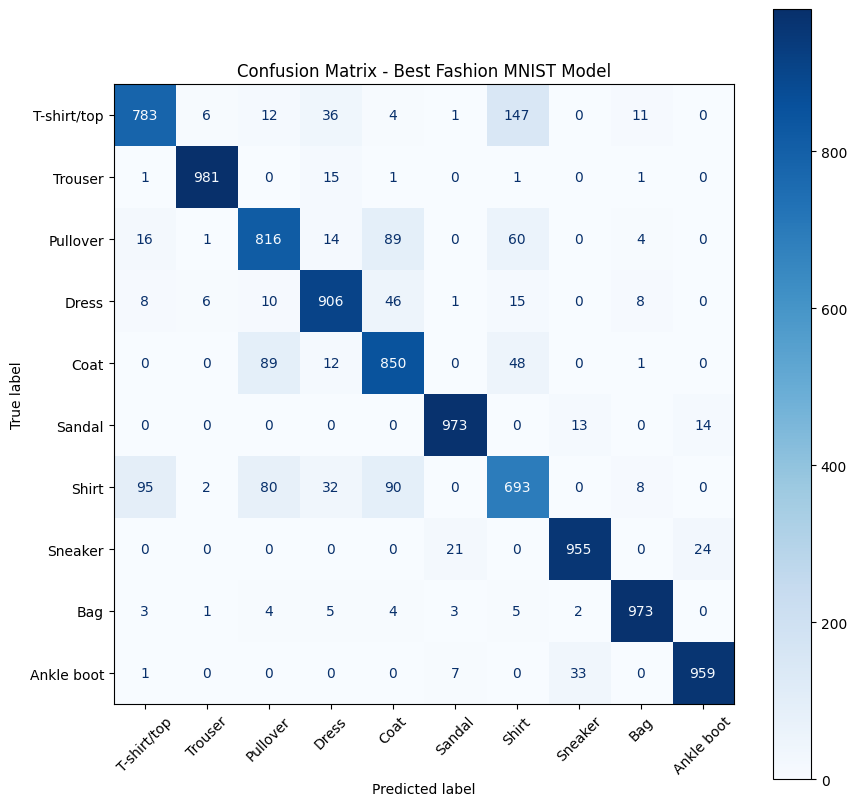

In [ ]:
# Initialize our absolute best, champion architecture (Experiment 10)
final_model = Sequential()
# Stretch the image into a 1D line
final_model.add(Flatten(input_shape=(28, 28)))
# Add the first massive hidden layer with 512 nodes
final_model.add(Dense(512, activation='relu'))
# Add the second hidden layer with 256 nodes
final_model.add(Dense(256, activation='relu'))
# Add the third hidden layer with 128 nodes
final_model.add(Dense(128, activation='relu'))
# Add the 10-node output layer using softmax
final_model.add(Dense(10, activation='softmax'))

# Compile the champion model
final_model.compile(loss='sparse_categorical_crossentropy', optimizer=Adam(learning_rate=0.001), metrics=['accuracy'])
# Train the champion model for a full 30 epochs to maximize learning, hiding the loading bar (verbose=0)
final_model.fit(X_train_scaled, y_train, epochs=30, batch_size=32, verbose=0)

# Ask the champion model to predict probabilities for all 10,000 test images
y_pred_probs = final_model.predict(X_test_scaled)
# Convert those 10 probabilities per image into a single hard prediction index (0 through 9)
y_pred_labels = np.argmax(y_pred_probs, axis=1)

# Print a header for the classification report
print("\n--- FINAL CLASSIFICATION REPORT ---")
# Print the detailed report card (Precision/Recall), swapping the numbers (0-9) for the actual clothing names
print(classification_report(y_test, y_pred_labels, target_names=class_names))

# Create a massive 10x10 drawing window for the confusion matrix so the boxes aren't squeezed
fig, ax = plt.subplots(figsize=(10, 10)) 
# Draw the 10x10 visual grid comparing true answers to guesses, colored blue, using clothing names
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_labels, cmap='Blues', display_labels=class_names, ax=ax)
# Add a title to the top of the confusion matrix graph
plt.title("Confusion Matrix - Best Fashion MNIST Model")
# Tilt the X-axis clothing names by 45 degrees so they don't overlap and become unreadable
plt.xticks(rotation=45) 
# Render the final confusion matrix to the screen
plt.show()